     L        S        Kg
0   10   0.3392  0.124814
1   11   0.6843  0.280334
2   12   1.1426  0.467153
3   13   1.6958  0.805454
4   14   2.3374  1.143106
5   15   3.0401  1.529282
6   16   3.7685  2.041966
7   17   4.5277  2.647133
8   18   5.3026  3.295486
9   19   6.0676  3.493082
10  20   6.8364  4.114050
11  25  10.3617  6.574807
12  30  13.8111  8.408693
Saved: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/plot_c/plot_c_RNA_Kg_vs_entropy.png


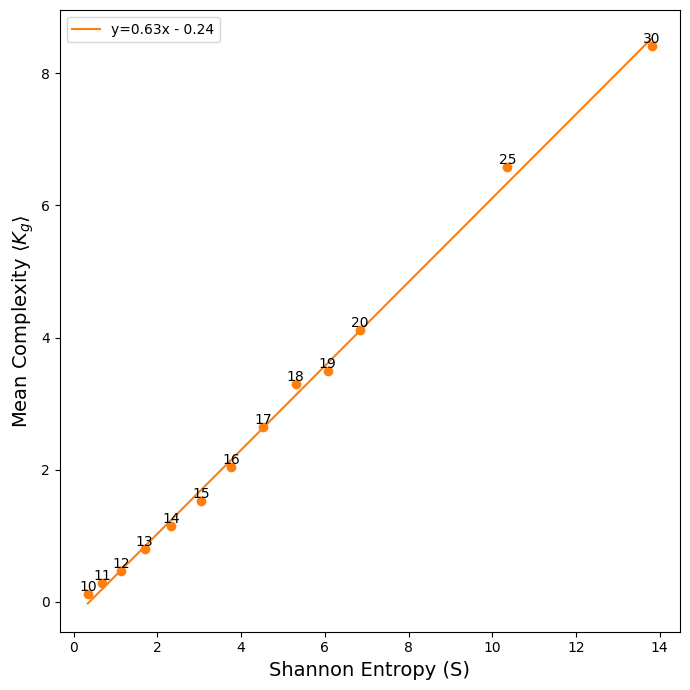

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ===================================
# Paths and settings
# ===================================

data_path = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/"
                 "circadian/mut_project_updates/figures/RNA/plot_c/"
                 "plot_c_files/Plot_C_data_RNA_N_Million_Samples.xlsx")

output_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/"
                  "circadian/mut_project_updates/figures/RNA/plot_c")

# ===================================
# Load data
# ===================================

df = pd.read_excel(data_path)

# Ensure numeric
df["L"] = pd.to_numeric(df["L"], errors="coerce")
df["S"] = pd.to_numeric(df["S"], errors="coerce")
df["Kg"] = pd.to_numeric(df["Kg"], errors="coerce")

df = df.dropna()

entropy_vals = df["S"].values
kg_vals = df["Kg"].values
labels = df["L"].astype(int).astype(str).values

print(df)

# ===================================
# Plot
# ===================================

def make_plot(x, y, labels):
    m, b = np.polyfit(x, y, 1)
    fit_line = m * x + b

    sign = "-" if b < 0 else "+"
    eq_label = f'y={m:.2f}x {sign} {abs(b):.2f}'

    plt.figure(figsize=(7, 7))
    plt.scatter(x, y, color='tab:orange')
    plt.plot(x, fit_line, color='tab:orange', label=eq_label)

    for xi, yi, lbl in zip(x, y, labels):
        plt.text(xi, yi, lbl, fontsize=10, ha='center', va='bottom')

    plt.xlabel("Shannon Entropy (S)", fontsize=14)
    plt.ylabel(r"Mean Complexity $\langle K_g \rangle$", fontsize=14)

    plt.legend()
    plt.tight_layout()

    out_path = output_dir / "plot_c_RNA_Kg_vs_entropy.png"
    plt.savefig(out_path, dpi=300)
    print(f"Saved: {out_path}")

    plt.show()
    plt.close()

# ===================================
# Make plot
# ===================================

make_plot(entropy_vals, kg_vals, labels)